# Features and Unsupervised Models

We describe each beat with 35 numbers (its shape, its rhythm, its frequencies), then we let two models decide what is unusual. The models never see the labels while they train. We only use the labels at the end, to check the result.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score
from m1_defect_anomaly_2026.unsupervised import subsample

from m1_defect_anomaly_2026.beats import load_record_data, load_split, extract_beat_matrix
from m1_defect_anomaly_2026.splits import DS1_train, DS2_test
from m1_defect_anomaly_2026.evaluation import evaluate_scores, select_threshold, build_table, save_table
from m1_defect_anomaly_2026.wavelets import cwt_scalogram, beat_dwt_matrix
from m1_defect_anomaly_2026.unsupervised import (build_split_matrix, feature_columns,
                                                 fit_isolation_forest, fit_one_class_svm,
                                                 anomaly_score)

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA = str(REPO_ROOT / "data" / "raw")
RESULTS_DIR = Path("../results/features_unsupervised")
FIG_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1 - Looking at a beat with wavelets

The FFT told us which frequencies are inside a beat, but not where. The wavelet transform keeps both. Let's compare a normal beat and a ventricular beat from record 208.

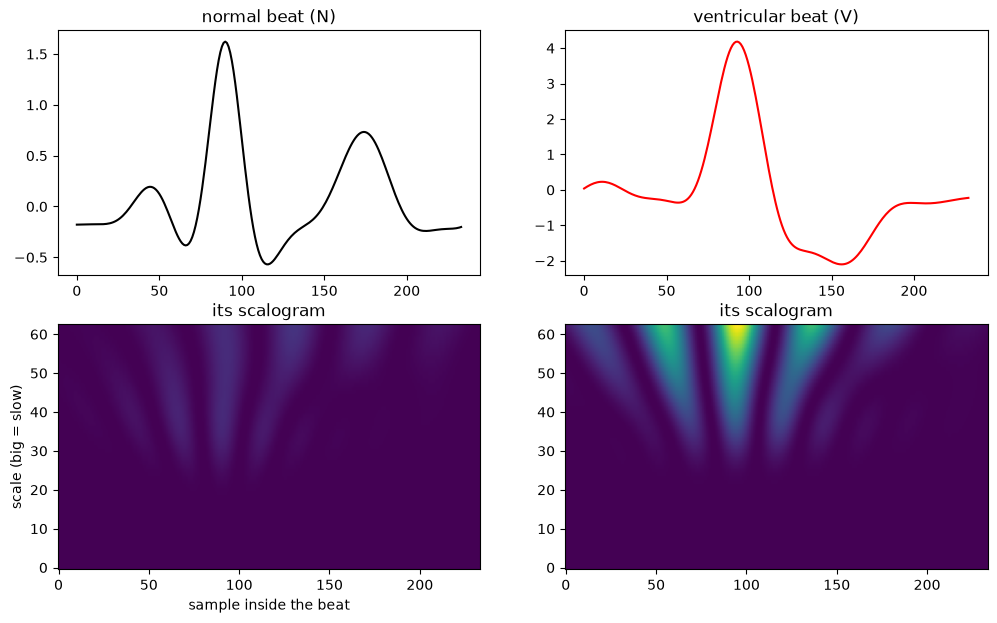

In [20]:
rec = load_record_data("208", data_dir=DATA)
beats = extract_beat_matrix(rec)

normal_beat = beats[np.where(rec.labels == "N")[0][0]]
v_beat = beats[np.where(rec.labels == "V")[0][0]]
freqs, power_n = cwt_scalogram(normal_beat)
freqs, power_v = cwt_scalogram(v_beat)
vmax = max(power_n.max(), power_v.max())

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(normal_beat, "k")
axes[0, 0].set_title("normal beat (N)")
axes[0, 1].plot(v_beat, "r")
axes[0, 1].set_title("ventricular beat (V)")

freqs, power = cwt_scalogram(normal_beat)
axes[1, 0].imshow(power, aspect="auto", origin="lower")
axes[1, 0].set_title("its scalogram")
axes[1, 0].set_ylabel("scale (big = slow)")
axes[1, 0].set_xlabel("sample inside the beat")
axes[1, 0].imshow(power_n, aspect="auto", origin="lower", vmin=0, vmax=vmax)


freqs, power = cwt_scalogram(v_beat)
axes[1, 1].imshow(power, aspect="auto", origin="lower")
axes[1, 1].set_title("its scalogram")
axes[1, 1].imshow(power_v, aspect="auto", origin="lower", vmin=0, vmax=vmax)

plt.savefig(FIG_DIR / "scalogram_normal_vs_v.png")

The two beats have a very different shape. The normal beat is made of three parts: a small bump, then a narrow and sharp peak, then a wider bump after it. The ventricular beat is one single large bump, with no small bump before, and it goes much lower after (-2 instead of -0.5). It is also more than twice as tall.

The two scalograms use the same colour scale, so we can compare them directly. The ventricular beat is much brighter, which means it carries much more energy. Its bright zone is also wider and stays around the middle of the window, where the beat happens. The normal beat is almost dark everywhere by comparison.

This is what the FFT could not tell us. The FFT would say that the ventricular beat has more energy, but not where. Here we see that this energy is concentrated at one precise moment inside the beat.

In [21]:
# average energy in each frequency band, per beat class
table208 = beat_dwt_matrix(beats)
table208["class"] = rec.labels
print(table208.groupby("class").mean().round(3).T)

class           F      N      Q      S      V
cA4_energy  0.968  0.963  0.973  0.973  0.995
cA4_std     4.193  1.977  4.702  2.047  5.465
cD4_energy  0.028  0.035  0.026  0.027  0.004
cD4_std     0.642  0.379  0.684  0.345  0.360
cD3_energy  0.001  0.001  0.000  0.001  0.000
cD3_std     0.079  0.040  0.063  0.035  0.047
cD2_energy  0.002  0.001  0.000  0.000  0.001
cD2_std     0.062  0.019  0.030  0.015  0.050
cD1_energy  0.000  0.000  0.000  0.000  0.000
cD1_std     0.019  0.005  0.009  0.004  0.014


The prediction is confirmed for the V beats. Ventricular beats put 0.995 of their energy in cA4, the slowest band, against 0.963 for normal beats. And in cD4, the next band up, normal beats have 0.035 while V beats have only 0.004, so almost nine times less. A wide beat really does move its energy towards the slow bands, exactly as expected.

But two things must be said about this table. First, all the classes have around 0.96 to 0.99 in cA4. The differences are real but small, so a model cannot separate the classes with cA4 alone. The band that actually separates them is cD4. Second, cD1, cD2 and cD3 are almost zero for every class. This is normal: our signals were filtered between 0.5 and 40 Hz, and with a sampling rate of 360 Hz these three bands cover the frequencies above 22 Hz, so the filter already removed almost everything there. These features carry almost no information, and we could remove them or use only 3 levels instead of 4.

## 2 - Building the feature matrix

Now we build one big table for the whole database: one line per beat, 35 columns. We save it so notebook 04 can use it again without computing everything a second time.

In [8]:
train = build_split_matrix(load_split(DS1_train, data_dir=DATA))
test = build_split_matrix(load_split(DS2_test, data_dir=DATA))

cols = feature_columns(train)
y_train = train["y"].to_numpy()
y_test = test["y"].to_numpy()

print("DS1 train:", train.shape)
print("DS2 test :", test.shape)
print("number of features:", len(cols))

DS1 train: (51003, 38)
DS2 test : (49692, 38)
number of features: 35


In [9]:
train.to_parquet(RESULTS_DIR / "features_ds1.parquet", index=False)
test.to_parquet(RESULTS_DIR / "features_ds2.parquet", index=False)

# do the features look different between the classes?
print(train.groupby("label")[["rms", "pre_rr", "spectral_centroid", "cA4_energy"]].mean().round(3))

         rms  pre_rr  spectral_centroid  cA4_energy
label                                              
F      1.112   0.605              4.298       0.969
N      0.985   0.803              4.993       0.968
Q      1.590   1.050              3.263       0.977
S      1.112   0.506              5.137       0.962
V      1.646   0.574              3.421       0.987


Each family of features brings something different, and no single one separates everything.

The rhythm feature pre_rr (the time before the beat) is the one that shows S beats. Supraventricular beats arrive early: 0.506 seconds after the previous beat, against 0.803 for normal beats. Their shape features are almost the same as normal beats (rms 1.11 against 0.98), so without the rhythm we would not see them at all.

The shape and frequency features are the ones that show V beats. They are bigger (rms 1.646 against 0.985) and slower (spectral_centroid 3.421 against 4.993, and cA4_energy 0.987 against 0.968).

This is exactly why we mix the four families in the same table. A model using only the shape would miss the S beats, and a model using only the rhythm would miss the V beats.

## 3 - Isolation Forest

This model cuts the space at random and counts how many cuts it needs to leave a beat alone. A beat that is different from the others gets separated very fast.

We train it on DS1 without the labels. Then we use the labels twice: once on DS1 to choose the threshold, once on DS2 to measure the result. Same protocol as notebook 02.

In [10]:
iso = fit_isolation_forest(train[cols])

iso_train = anomaly_score(iso, train[cols])
iso_test = anomaly_score(iso, test[cols])

print("average score of normal beats :", round(iso_test[y_test == 0].mean(), 4))
print("average score of anomaly beats:", round(iso_test[y_test == 1].mean(), 4))

average score of normal beats : 0.4245
average score of anomaly beats: 0.4927


The anomaly beats have the higher average score (0.4927 against 0.4245), so the sign of the score is correct: a high score really means anomalous.

But the two averages are close, and the gap is small. This does not mean the model is bad, it means the averages alone are not enough to judge it. Many anomalies probably get a normal score, and it is the ranking of the beats that matters, not the distance between the two averages. That is exactly what the ROC-AUC measures, so we look at it in the next cell.

In [11]:
iso_threshold, iso_f1_train = select_threshold(y_train, iso_train)
iso_result = evaluate_scores(y_test, iso_test, iso_threshold, "Isolation Forest")

print("F1 on DS1:", round(iso_f1_train, 3))
print("F1 on DS2:", round(iso_result["f1"], 3))
print("ROC-AUC on DS2:", round(iso_result["roc_auc"], 3))

F1 on DS1: 0.679
F1 on DS2: 0.427
ROC-AUC on DS2: 0.836


ROC-AUC on DS2 is 0.836. This is the best result of the project so far: better than the spectral features of notebook 02 (0.773) and much better than CUSUM (0.680). F1 is 0.427, also above the best of notebook 02 (0.373). The 35 features clearly bring something that the raw signal detectors could not see.

## 4 - One-Class SVM

This model works with a completely different idea. It draws a border around the area where the beats live, and everything outside is an anomaly.

Isolation Forest cuts one feature at a time, so its cuts are always straight along the axes. The SVM border can be diagonal, so it can see a beat where each feature alone looks normal but the mix does not.

It is trained on 20 000 beats taken at random instead of all of DS1, because it compares every beat with every other one and that becomes slow.

In [12]:
svm = fit_one_class_svm(train[cols])

svm_train = anomaly_score(svm, train[cols])
svm_test = anomaly_score(svm, test[cols])

svm_threshold, svm_f1_train = select_threshold(y_train, svm_train)
svm_result = evaluate_scores(y_test, svm_test, svm_threshold, "One-Class SVM")

print("F1 on DS1:", round(svm_f1_train, 3))
print("F1 on DS2:", round(svm_result["f1"], 3))
print("ROC-AUC on DS2:", round(svm_result["roc_auc"], 3))

F1 on DS1: 0.475
F1 on DS2: 0.275
ROC-AUC on DS2: 0.687


ROC-AUC is 0.687 and F1 is 0.275. The One-Class SVM is clearly below Isolation Forest (0.836 and 0.427), and also below the spectral features of notebook 02 (0.773 and 0.373). Its F1 of 0.275 is at the same level as the Z-score with a 10-second window (0.276), which was one of the weakest methods of the previous notebook.

The drop between DS1 (0.475) and DS2 (0.275) is even bigger than for Isolation Forest, so the threshold travels badly from one group of patients to the other here too.

Before saying that the SVM is a bad model, we test two possible reasons in the next section.

## 5 - Why is the SVM weaker?

First idea: the scaling. The SVM measures distances, so a feature with very big values could hide all the others. StandardScaler uses the mean and the standard deviation, and both are sensitive to extreme beats. RobustScaler uses the median instead, so extreme beats cannot disturb it.

In [13]:
robust = make_pipeline(RobustScaler(), OneClassSVM(kernel="rbf", nu=0.1, gamma="scale"))
robust.fit(subsample(train[cols], 20000, 42))

print("with RobustScaler:", round(roc_auc_score(y_test, anomaly_score(robust, test[cols])), 3))

with RobustScaler: 0.66


With RobustScaler we get 0.66, so slightly worse than with StandardScaler (0.687). Changing the way we scale the features does not help, so the scaling is not the reason why the SVM is weak. We can drop this explanation and test the second one.

Second idea: the training set is dirty. The SVM draws its border around what we give it, and DS1 contains around 11% real anomalies. So those anomalies help to define what the model calls "normal", and the border becomes too large. To test this, we train it again on the normal beats of DS1 only.

In [14]:
clean_train = train[train.y == 0]
svm_clean = fit_one_class_svm(clean_train[cols])

print("trained on normal beats only:", round(roc_auc_score(y_test, anomaly_score(svm_clean, test[cols])), 3))

trained on normal beats only: 0.877


0.877, which is 0.19 higher than before, and even higher than Isolation Forest (0.836).

Now we have the answer. The features and the kernel did not change: only the training beats changed. So the problem was never the features or the model itself, it is that DS1 contains around 11% real anomalies, and the SVM draws its border around everything we give it. Those anomalies push the border outwards, and beats that should be outside end up inside.

Isolation Forest is much less affected, because a strange beat is isolated after a few cuts even if similar beats exist in the training set.

Careful with this 0.877: to build this training set we used the labels to keep only the normal beats. So this model got help that Isolation Forest never had. It answers the question "how good could the SVM be with a clean training set", which explains why it was weak, but it cannot go in the comparison table. In the table the SVM keeps 0.687, the result it obtained without ever using the labels.

## 6 - Comparison table

In [15]:
old = pd.read_csv("../results/statistical_baseline/comparison_table.csv")
results = old.to_dict("records") + [iso_result, svm_result]

table = build_table(results)
table[["method", "precision", "recall", "f1", "roc_auc"]]

,method,precision,recall,f1,roc_auc
0,Isolation Forest,0.342546,0.566031,0.426803,0.836036
1,Spectral features,0.297327,0.501834,0.373413,0.773129
2,CUSUM (k=0.5),0.410245,0.334923,0.368777,0.679941
3,Z-score (10s window),0.651847,0.174798,0.275673,0.614689
4,One-Class SVM,0.200185,0.437454,0.274675,0.687392
5,Random baseline,0.109734,0.995598,0.197680,0.499588
6,Z-score (1s window),0.109636,0.996515,0.197538,0.274422


Isolation Forest is now first on both F1 (0.427) and ROC-AUC (0.836). It takes the place of the spectral features, which were the best method of notebook 02. Moving from the raw signal to a table of 35 features clearly helped.


In [16]:
save_table(table, csv_path=str(RESULTS_DIR / "comparison_table.csv"),
           md_path=str(RESULTS_DIR / "comparison_table.md"))

## 7 - Do the two models find the same beats?

The global score does not say if the two models fail on the same beats or on different ones. That is more interesting, because the two methods work in opposite ways.

In [17]:
test["iso_flag"] = (iso_test >= iso_threshold).astype(int)
test["svm_flag"] = (svm_test >= svm_threshold).astype(int)

both = ((test.iso_flag == 1) & (test.svm_flag == 1)).sum()
only_iso = ((test.iso_flag == 1) & (test.svm_flag == 0)).sum()
only_svm = ((test.iso_flag == 0) & (test.svm_flag == 1)).sum()

print("flagged by both models  :", both)
print("only by Isolation Forest:", only_iso)
print("only by One-Class SVM   :", only_svm)

flagged by both models  : 7779
only by Isolation Forest: 1230
only by One-Class SVM   : 4135


The two models agree on 7779 beats, but they also disagree a lot: 1230 beats are flagged only by Isolation Forest and 4135 only by the SVM. So out of the 13144 beats flagged by at least one model, only 59% are flagged by both.

In [18]:
# among the real anomalies, which class does each model catch?
anomalies = test[test.y == 1]
per_class = anomalies.groupby("label").agg(n_beats=("y", "size"),
                                           caught_by_iso=("iso_flag", "mean"),
                                           caught_by_svm=("svm_flag", "mean"))
print(per_class.round(3).to_string())

       n_beats  caught_by_iso  caught_by_svm
label                                       
F          388          0.106          0.126
Q            7          1.000          1.000
S         1837          0.396          0.368
V         3220          0.717          0.513


V beats are the ones both models catch best, and Isolation Forest is clearly better (0.717 against 0.513). A ventricular beat is wide and big, so it sits far from the others and gets isolated fast.

S beats are around 0.38 for both, so more than half are missed. Their shape is close to normal beats, only their timing is different.

F beats are missed by both (0.106 and 0.126). A fusion beat is a mix of normal and ventricular, so its features sit between the two classes and it never looks far enough from normal.

Q is caught perfectly by both, but there are only 7 beats, so this number means nothing.

The SVM does not catch a class that Isolation Forest misses, so the two models are not complementary. Isolation Forest is simply better here, and S and F are what still fails.